**Install Required Libraries**

In [1]:
# Install necessary libraries
!pip install catboost lightgbm xgboost autogluon shap dask[dataframe] scikit-optimize

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.4/40.4 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of dask-expr to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.0/117.0 kB 5.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.5/259.5 kB 12.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could tak

**Import Libraries**

In [1]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from lightgbm import LGBMRegressor
from autogluon.tabular import TabularPredictor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import shap
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
from tqdm import tqdm

**Load and Preprocess the Dataset**

In [2]:
# Load and preprocess the dataset
data = pd.read_csv('/content/Final_Cleaned_Voyage_Data.csv', parse_dates=['DepartureTime', 'ArrivalTime'], infer_datetime_format=True)

# Convert datetimes and calculate duration
data['DepartureTime'] = pd.to_datetime(data['DepartureTime'], format="%m/%d/%Y %H:%M")
data['ArrivalTime'] = pd.to_datetime(data['ArrivalTime'], format="%m/%d/%Y %H:%M")
data['TravelTime_seconds'] = (data['ArrivalTime'] - data['DepartureTime']).dt.total_seconds()

# Extract departure hour
data['DepartureHour'] = data['DepartureTime'].dt.hour

<ipython-input-2-cbb3cf3109e9>:2: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  data = pd.read_csv('/content/Final_Cleaned_Voyage_Data.csv', parse_dates=['DepartureTime', 'ArrivalTime'], infer_datetime_format=True)


**Define Features and Target Variable**

In [3]:
# Define features and target variable
numeric_features = ['LATd', 'LONd', 'LATa', 'LONa', 'Voyage_Distance_Km', 'draft_km', 'Average_Speed_Kmph',
                    'Std_SpeedKMpH', 'Avg_Course', 'breadthKM', 'DepartureHour']
categorical_features = ['vessel_type']

# Preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # Handle missing values
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Handle missing values
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))  # Sparse=False for better compatibility
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Define features and target variable
X = data[numeric_features + categorical_features]
y = data['TravelTime_seconds']

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocess the data
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

**Hyperparameter Tuning for Extra Trees**

In [4]:
# Hyperparameter Tuning for Extra Trees
et_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

et_model = ExtraTreesRegressor(random_state=42)
et_grid_search = BayesSearchCV(et_model, et_param_grid, cv=5, scoring='neg_mean_squared_error', n_iter=10, random_state=42)
et_grid_search.fit(X_train, y_train)
best_et_model = et_grid_search.best_estimator_
et_y_pred = best_et_model.predict(X_test)

print("Best Hyperparameters for Extra Trees:")
print(et_grid_search.best_params_)

/usr/local/lib/python3.11/dist-packages/skopt/space/space.py:116: UserWarning: Dimension [100, 200] was inferred to Integer(low=100, high=200, prior='uniform', transform='identity'). In upcoming versions of scikit-optimize, it will be inferred to Categorical(categories=(100, 200), prior=None). See the documentation of the check_dimension function for the upcoming API.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/skopt/space/space.py:116: UserWarning: Dimension [10, 20] was inferred to Integer(low=10, high=20, prior='uniform', transform='identity'). In upcoming versions of scikit-optimize, it will be inferred to Categorical(categories=(10, 20), prior=None). See the documentation of the check_dimension function for the upcoming API.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/skopt/space/space.py:116: UserWarning: Dimension [2, 5] was inferred to Integer(low=2, high=5, prior='uniform', transform='identity'). In upcoming versions of scikit-optimize, it will be inf

Best Hyperparameters for Extra Trees:
OrderedDict([('max_depth', 18), ('min_samples_leaf', 1), ('min_samples_split', 4), ('n_estimators', 180)])


**Hyperparameter Tuning for LightGBM**

In [5]:
# Define the hyperparameter search space for LightGBM
lgb_param_grid = {
    'num_leaves': Integer(32, 64),  # Integer range for num_leaves
    'max_depth': Integer(5, 10),    # Integer range for max_depth
    'learning_rate': Real(0.01, 0.1, prior='log-uniform'),  # Log-uniform range for learning_rate
    'n_estimators': Integer(100, 200)  # Integer range for n_estimators
}

# Initialize the LightGBM model
lgb_model = LGBMRegressor(random_state=42)

# Initialize BayesSearchCV
lgb_bayes_search = BayesSearchCV(
    lgb_model,
    lgb_param_grid,
    n_iter=10,  # Number of iterations
    cv=5,       # 5-fold cross-validation
    scoring='neg_mean_squared_error',  # Scoring metric
    random_state=42,
    n_jobs=-1   # Use all available cores
)

# Fit the BayesSearchCV to the training data
lgb_bayes_search.fit(X_train, y_train)

# Get the best model and its hyperparameters
best_lgb_model = lgb_bayes_search.best_estimator_
lgb_y_pred = best_lgb_model.predict(X_test)

# Print the best hyperparameters
print("Best Hyperparameters for LightGBM (BayesSearchCV):")
print(lgb_bayes_search.best_params_)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001793 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2565
[LightGBM] [Info] Number of data points in the train set: 15015, number of used features: 16
[LightGBM] [Info] Start training from score 313731.456210
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

**Create Meta-Features and Train Random Forest Meta-Learner**

In [6]:
# Create meta-features from base model predictions (only ExtraTrees and LightGBM)
meta_features = pd.DataFrame({'ExtraTrees': et_y_pred, 'LightGBM': lgb_y_pred})

# Define the hyperparameter search space for Random Forest Meta-Learner
rf_param_grid = {
    'n_estimators': Integer(100, 200),  # Number of trees in the forest
    'max_depth': Integer(5, 20),        # Maximum depth of the tree
    'min_samples_split': Integer(2, 10),  # Minimum number of samples required to split a node
    'min_samples_leaf': Integer(1, 5)   # Minimum number of samples required at each leaf node
}

# Initialize the Random Forest model
rf_model = RandomForestRegressor(random_state=42)

# Initialize BayesSearchCV
rf_bayes_search = BayesSearchCV(
    rf_model,
    rf_param_grid,
    n_iter=10,  # Number of iterations
    cv=5,       # 5-fold cross-validation
    scoring='neg_mean_squared_error',  # Scoring metric
    random_state=42,
    n_jobs=-1   # Use all available cores
)

# Fit the BayesSearchCV to the meta-features and target
rf_bayes_search.fit(meta_features, y_test)

# Get the best model and its hyperparameters
best_rf_model = rf_bayes_search.best_estimator_
rf_y_pred = best_rf_model.predict(meta_features)

# Print the best hyperparameters
print("Best Hyperparameters for Random Forest Meta-Learner (BayesSearchCV):")
print(rf_bayes_search.best_params_)

Best Hyperparameters for Random Forest Meta-Learner (BayesSearchCV):
OrderedDict([('max_depth', 17), ('min_samples_leaf', 3), ('min_samples_split', 6), ('n_estimators', 172)])


**Evaluate Stacking Ensemble Performance**

In [7]:
# Evaluate stacking ensemble performance
ensemble_mae = mean_absolute_error(y_test, rf_y_pred)
ensemble_mse = mean_squared_error(y_test, rf_y_pred)
ensemble_r2 = r2_score(y_test, rf_y_pred)

print("Stacking Ensemble (Random Forest Meta-Learner):")
print("Mean Absolute Error:", ensemble_mae)
print("Mean Squared Error:", ensemble_mse)
print("R-squared:", ensemble_r2)

Stacking Ensemble (Random Forest Meta-Learner):
Mean Absolute Error: 1823.5077987987518
Mean Squared Error: 64692014.91495556
R-squared: 0.999522299538557


**Cross-Validation for Random Forest Meta-Learner**

In [8]:
# Cross-validation for Random Forest Meta-Learner
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'neg_mean_squared_error': 'neg_mean_squared_error',
           'neg_mean_absolute_error': 'neg_mean_absolute_error',
           'r2': 'r2'}
cv_results_rf = cross_validate(best_rf_model, meta_features, y_test, cv=kf, scoring=scoring)
print("Random Forest Meta-learner cross-validation results:")
print("Mean MAE:", -cv_results_rf['test_neg_mean_absolute_error'].mean())
print("Mean MSE:", -cv_results_rf['test_neg_mean_squared_error'].mean())
print("Mean R2:", cv_results_rf['test_r2'].mean())

Random Forest Meta-learner cross-validation results:
Mean MAE: 2987.662722256546
Mean MSE: 169187621.5364978
Mean R2: 0.998732411020077


**Compute MAPE for Models**

In [9]:
# Mean Absolute Percentage Error (MAPE)
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    non_zero_indices = y_true != 0
    y_true_non_zero = y_true[non_zero_indices]
    y_pred_non_zero = y_pred[non_zero_indices]
    return np.mean(np.abs((y_true_non_zero - y_pred_non_zero) / y_true_non_zero)) * 100

# Compute MAPE for the Stacking Model
stacking_mape = mean_absolute_percentage_error(y_test, rf_y_pred)
print(f"Stacking Ensemble (Random Forest Meta-Learner) MAPE: {stacking_mape:.2f}%")

# Compute MAPE for individual models
et_mape = mean_absolute_percentage_error(y_test, et_y_pred)
lgb_mape = mean_absolute_percentage_error(y_test, lgb_y_pred)

print(f"Extra Trees Regressor MAPE: {et_mape:.2f}%")
print(f"LightGBM Regressor MAPE: {lgb_mape:.2f}%")

Stacking Ensemble (Random Forest Meta-Learner) MAPE: 0.32%
Extra Trees Regressor MAPE: 0.46%
LightGBM Regressor MAPE: 1.33%


**Plot Actual vs. Predicted**

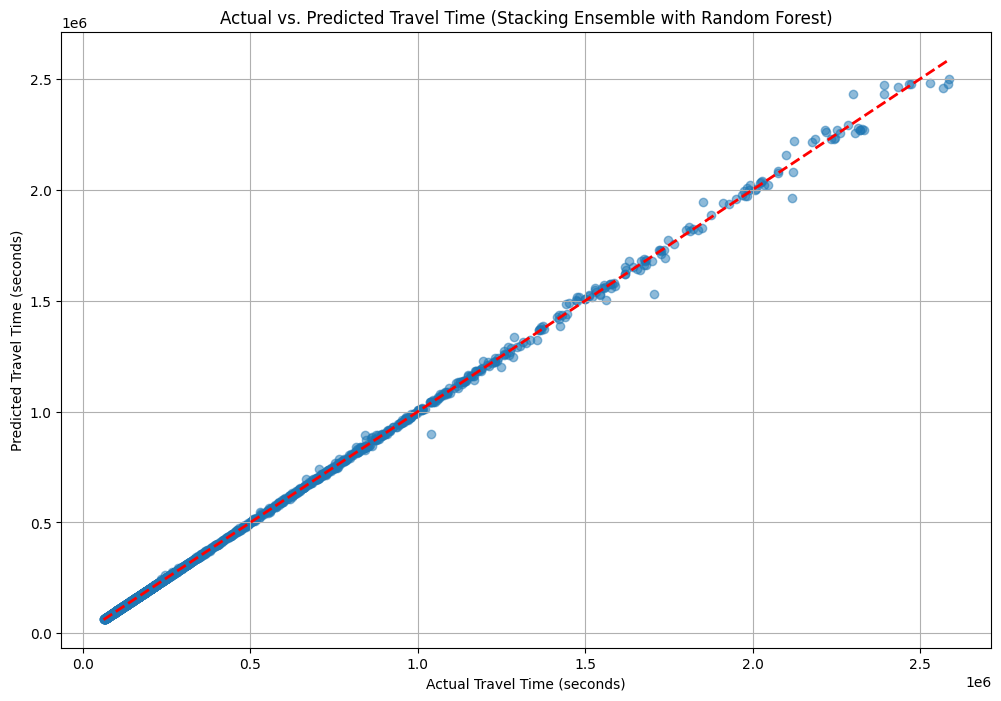

In [10]:
# Plot Actual vs. Predicted
plt.figure(figsize=(12, 8))
plt.scatter(y_test, rf_y_pred, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--', lw=2)
plt.title('Actual vs. Predicted Travel Time (Stacking Ensemble with Random Forest)')
plt.xlabel('Actual Travel Time (seconds)')
plt.ylabel('Predicted Travel Time (seconds)')
plt.grid(True)
plt.show()